<a href="https://colab.research.google.com/github/cwf2/dices-examples/blob/main/colab/Dead%20Flavians.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

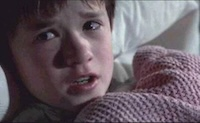
# Who speaks to dead characters in Flavian Epic?

### Prereqs

In [ ]:
# DICES client
%pip install git+https://github.com/cwf2/dices-client

# Waffle chart package
%pip install pywaffle

  Cloning https://github.com/cwf2/dices-client to /tmp/pip-req-build-w73dl22x
  Running command git clone --filter=blob:none --quiet https://github.com/cwf2/dices-client /tmp/pip-req-build-w73dl22x
  Resolved https://github.com/cwf2/dices-client to commit 4a2609b7edb52f5134df44d66a62dee11b6a40ea
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for dices-client: filename=dices_client-0.0.2-py3-none-any.whl size=27527 sha256=5c3e795e13fc5f9a1147be6b09bf2d2c87b830e48329c2a47680a61972c2f3ca
  Stored in directory: /tmp/pip-ephem-wheel-cache-_1k4msai/wheels/4f/e0/1a/88318a92ba1bca3ef005e9e3c341a33e7217e03d62434cf216
Successfully built dices-client
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 47.8 MB/s eta 0:00:00


### Import statements

In [ ]:
from dicesapi import DicesAPI
from pywaffle import Waffle
import matplotlib.pyplot as plt

## Collect data
### Download speeches by three Flavian epic poets

In [ ]:
# connect to api
api = DicesAPI()

# download speeches by Flavian authors
speeches = (
    api.getSpeeches(author_name="Silius") +
    api.getSpeeches(author_name="Statius") +
    api.getSpeeches(author_name="Valerius Flaccus")
).sorted()

# check right number of authors
author_names = set([s.author.name for s in speeches])
print(f"Got {len(speeches)} speeches by {len(author_names)} authors.")

Got 819 speeches by 3 authors.


In [ ]:
# spot check results
print("First five speeches:")

for i, speech in enumerate(speeches[:5]):
    print(f"{i+1}. {speech.work.title} {speech.l_range}: {speech.getSpkrString()} -> {speech.getAddrString()}")

First five speeches:
1. Punica 1.42-1.54: Juno -> river Aufidus, river Ticinus
2. Punica 1.106-1.119: Hamilcar -> Hannibal, dead Dido
3. Punica 1.125-1.137: Massylian priestess -> Hamilcar
4. Punica 1.340-1.344: Hannibal -> Carthaginians
5. Punica 1.384-1.386: Murrus -> Aradus


### Sort by changed state of speaker, addressee

Create a dictionary with every combination of speaker/addressee state. Go through speeches one by one, and add to the list for each speaker/addressee combo.

**NB** Speeches can be added to the count for more than one category, for example if one addressee is dead and another is alive. But each speech can only be added to each category once (`set.add()` won't accept duplicate entries).

In [ ]:
def index_speaker_addressee_states(speech_set):
    '''This function indexes speeches by speaker/addressee state.

        It produces a dictionary where keys are e.g. "alive-dead"
        and values are a list of speeches where e.g. at least one
        speaker is alive and at least one speaker is dead.
    '''

    # create a dictionary where key is spkr-addr state combo, values are sets
    index = dict()
    states = ["alive", "dead", "divine"]
    for spkr_state in states:
        for addr_state in states:
            index[f"{spkr_state}-{addr_state}"] = set()

    # iterate over speeches
    for s in speech_set:
        # Determine the states of all speakers in the current speech
        speaker_states_for_this_speech = set()
        for spkr in s.spkr:
            if spkr.being == "divine": # Check divine status first
                speaker_states_for_this_speech.add("divine")
            elif spkr.changed == "death": # Then check death status
                speaker_states_for_this_speech.add("dead")
            else: # Otherwise, it's alive
                speaker_states_for_this_speech.add("alive")

        # Determine the states of all addressees in the current speech
        addressee_states_for_this_speech = set()
        for addr in s.addr:
            if addr.being == "divine": # Check divine status first
                addressee_states_for_this_speech.add("divine")
            elif addr.changed == "death": # Then check death status
                addressee_states_for_this_speech.add("dead")
            else: # Otherwise, it's alive
                addressee_states_for_this_speech.add("alive")

        # Add the speech to all relevant combined categories
        for spkr_state in speaker_states_for_this_speech:
            for addr_state in addressee_states_for_this_speech:
                index[f"{spkr_state}-{addr_state}"].add(s)

    return index

## Results

I saw the waffle chart [here](https://medium.com/data-science/9-visualizations-to-show-proportions-or-percentages-instead-of-a-pie-chart-4e8d81617451). I tried a couple of pie charts but because the difference between the biggest portion and all the others is so great, it's hard to make it look good. But you might be able to do better than I can.

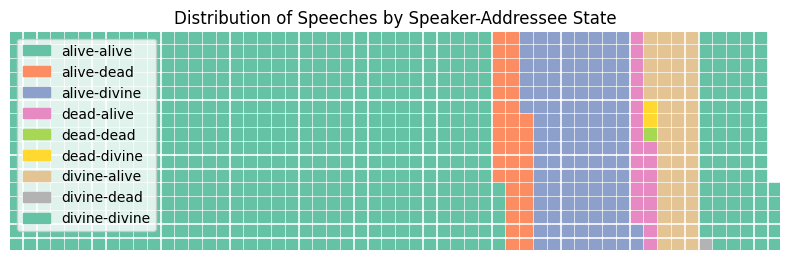

In [ ]:
# calculate index for all speeches
index = index_speaker_addressee_states(speeches)

# count speeches in each category
tally = dict()
for k, v in index.items():
    tally[k] = len(v)

# plot
fig = plt.figure(
    FigureClass=Waffle,
    rows=16,
    values=list(tally.values()),
    labels=list(tally.keys()),
    legend={'loc': 'upper left', 'bbox_to_anchor': (0, 1)},
    figsize=(8, 6)
)
plt.title('Distribution of Speeches by Speaker-Addressee State')
plt.show()


Processing author: Silius


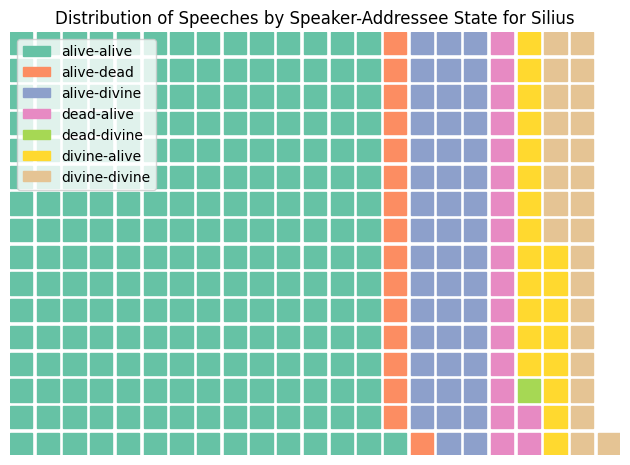


Processing author: Statius


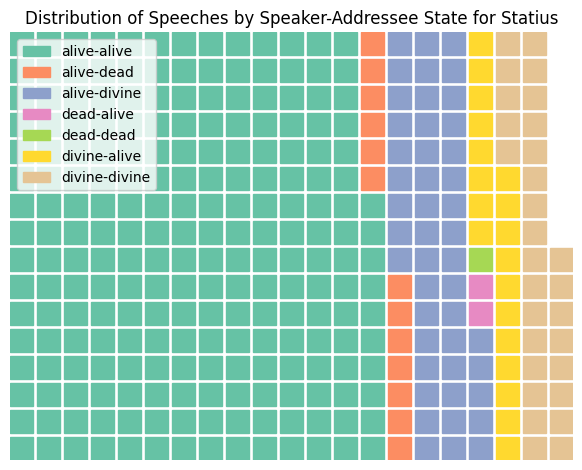


Processing author: Valerius Flaccus


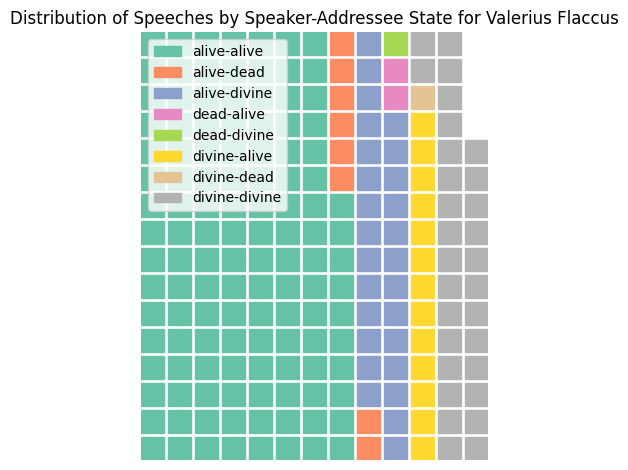

In [ ]:
for author_name in sorted(list(author_names)):
    print(f"\nProcessing author: {author_name}")

    # Filter speeches for the current author
    author_speeches = [s for s in speeches if s.author.name == author_name]

    # Run our indexing function
    index = index_speaker_addressee_states(author_speeches)

    # Count speeches in each category
    #  - omit zero counts
    tally = dict()
    for k, v in index.items():
        if len(v) > 0:
            tally[k] = len(v)

    # plot
    fig = plt.figure(
        FigureClass=Waffle,
        rows=16, # Keeping rows consistent with the previous plot
        values=list(tally.values()),
        labels=list(tally.keys()),
        legend={'loc': 'upper left', 'bbox_to_anchor': (0, 1)},
        # figsize=(8, 6)
    )
    plt.title(f'Distribution of Speeches by Speaker-Addressee State for {author_name}')
    plt.show()

In [ ]:
# Back to the entire data set
index = index_speaker_addressee_states(speeches)

# just counts
for k, v in index.items():
    print(f"{k}: {len(v)}")

alive-alive: 565
alive-dead: 37
alive-divine: 120
dead-alive: 22
dead-dead: 1
dead-divine: 2
divine-alive: 53
divine-dead: 1
divine-divine: 84


In [ ]:
# list individual speeches for dead people
for k, v in index.items():
    if "dead" in k:
        print(f"{k}:")
        for s in sorted(v):
            print(f"\t{s.work.title} {s.l_range}: {s.getSpkrString()} -> {s.getAddrString()}")

alive-dead:
	Punica 1.106-1.119: Hamilcar -> Hannibal, dead Dido
	Punica 5.588-5.591: Hannibal -> Carthaginians, dead Sychaeus
	Punica 5.594-5.602: Hannibal -> dead Sychaeus
	Punica 10.572-10.575: Hannibal -> dead L. Aemilius Paullus
	Punica 13.450-13.456: Publius Cornelius Scipio Africanus -> ghost of Appius Claudius Pulcher (consul 212)
	Punica 13.517-13.522: Publius Cornelius Scipio Africanus -> ghost of Sibyl
	Punica 13.623-13.627: Publius Cornelius Scipio Africanus -> ghost of Pomponia
	Punica 13.654-13.660: Publius Cornelius Scipio Africanus -> ghost of Gnaeus Cornelius Scipio Calvus, ghost of Publius Cornelius Scipio the Elder
	Punica 13.697-13.702: Publius Cornelius Scipio Africanus -> ghost of Gnaeus Cornelius Scipio Calvus, ghost of Publius Cornelius Scipio the Elder, gods
	Punica 13.711-13.715: Publius Cornelius Scipio Africanus -> ghost of L. Aemilius Paullus
	Punica 13.738-13.743: Publius Cornelius Scipio Africanus -> ghost of Hamilcar
	Punica 13.767-13.771: Publius Cornel